### 1. 문제 정의(목표설정)
 - 버섯의 특징을 활용해서 식용 / 독 구분
 - 결정트리 모델 시각화
 - 특성 중요도 확인

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

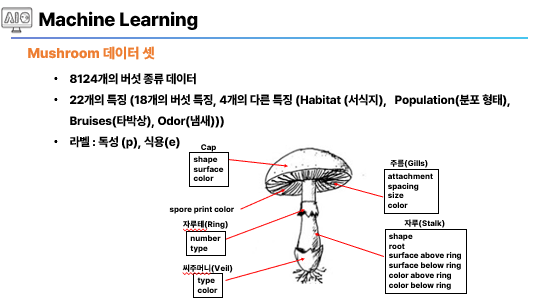
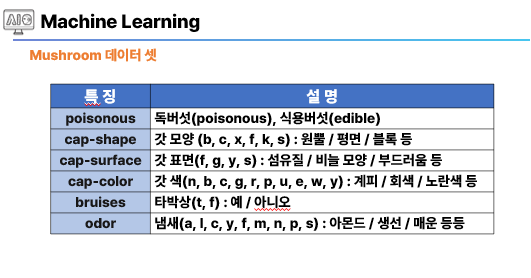
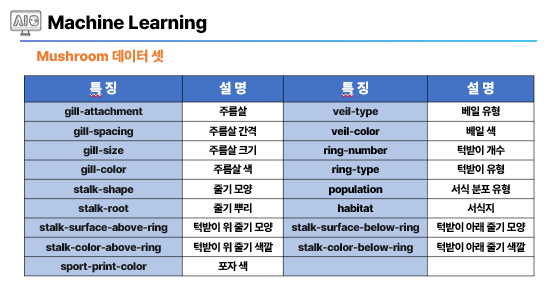

In [2]:
# 데이터 불러오기 진행
data = pd.read_csv('./data/mushroom.csv')
data

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [3]:
# 데이터 확인
data.info()

# Non-Null Count - non-null = 결측치 없음
# 현재 데이터는 문자열로 구성 (object는 보통 문자열)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [4]:
# head(n) = 상위 n개의 데이터를 불러오는 방법
data.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
# tail(n) = 하위 n개의 데이터를 불러오는 방법
data.tail()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [6]:
# 기술 통계치 확인하기
# describe()
data.describe()

# count = 전체 갯수
# unique = 고유 값의 갯수
# top = 최빈 값(빈도 수 가 많은 데이터)
# freq = 최빈 수치

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [7]:
# 문제 데이터와 정답 데이터 분할하기
# 분할 방법의 종류 (iloc, loc, drop)
X = data.drop('poisonous', axis = 1)
y = data['poisonous']

In [8]:
X

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


In [9]:
# 탐색적 데이터 분석
# 시각화를 활용해서 두드러지게 보이는 특징들을 확인해보자
# 시각화를 위해서 seaborn 라이브러리 활용
import seaborn as sns

<Axes: xlabel='cap-shape', ylabel='count'>

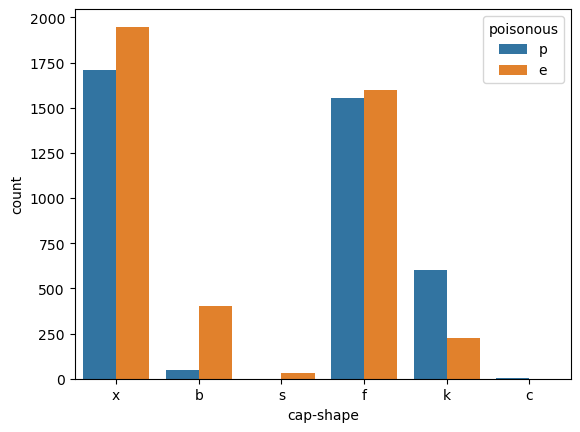

In [10]:
# sns.countplot() : 막대그래프 만들어줌
# 판다스에서는 sns.countplot() 사용하는게 더 좋음
sns.countplot(
    data = data,   # 데이터프레임 지정
    x = 'cap-shape',   # 어떤 컬럼을 x축에 지정할것인지
    hue = 'poisonous'   # 어떤 컬럼의 고유 값을 숫자로 세서 그려줄것인가(범례 포함)
)

# matplotlib로 사용시
# poisonous 컬럼 value_cout() 지정
# cap-shape 컬럼 value_cout() 지정
# bar차트 그리기(내부 이름 지정/ 범례 호출 함수 지정)


<Axes: xlabel='cap-color', ylabel='count'>

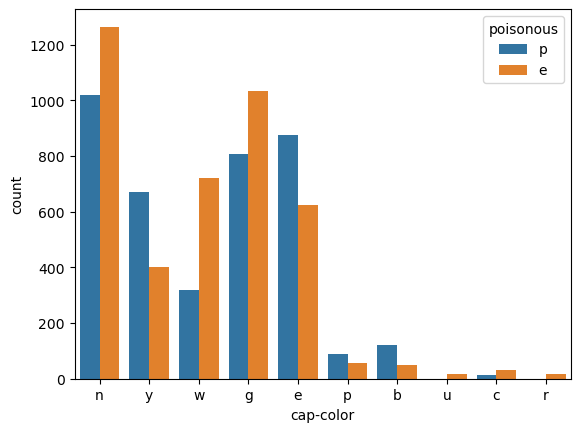

In [11]:
sns.countplot(
    data = data,   # 데이터프레임 지정
    x = 'cap-color',   # 어떤 컬럼을 x축에 지정할것인지
    hue = 'poisonous'   # 어떤 컬럼의 고유 값을 숫자로 세서 그려줄것인가(범례 포함)
)

In [12]:
# 모델링
# 1. 현재 데이터는 문자형 => 수치 계산을 통해서 예측 불가능
#   문자 데이터를 수치로 바꿔주는 인코딩 작업
# 2. 훈련 / 평가 데이터 분할
# 3. 모델 불러오기 및 학습 진행 => 성능 평가
# 4. 교차검증
# 5. 특성 중요도 확인 => 결과 리포트

In [13]:
# 인코딩 방법 - 2가지의 방법이 잇음
# 1. Label Encoding
# 2. one-hot Encoding(더미 변수화) - 채택

In [14]:
# 라벨 인코딩 실습
# sklearn.preprocessing : 전처리 도구 모음집
from sklearn.preprocessing import LabelEncoder

In [15]:
labeler = LabelEncoder()   # 객체 생성
labeler.fit(data['poisonous'])   # 라벨인코딩 변환 패턴 학습
label = labeler.transform(data['poisonous'])   # 실제 데이터 변환

In [16]:
labeler.classes_

array(['e', 'p'], dtype=object)

In [17]:
labeler.inverse_transform(label)

array(['p', 'e', 'e', ..., 'e', 'p', 'e'], shape=(8124,), dtype=object)

In [18]:
# 원 핫 인코딩 진행
X_oh = pd.get_dummies(X, dtype = int)   # dtype 변환을 시켜줘야함
X_oh

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
8121,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8122,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


### 인코딩 시 주의점
 - 훈련 데이터와 평가 데이터로 나눠진 경우 각각 데이터에 동일한 방식으로 인코딩을 진행
 - 인코딩 방식을 섞어서 사용하면 안됨

In [19]:
# 훈련 평가 데이터 분할하기
# train_test_split 합수 사용하기
from sklearn.model_selection import train_test_split

In [20]:
# X_oh = 문제(특성 데이터), y = 정답(예측 데이터)
# random_state (랜덤 방식 고정), train_size (훈련 데이터 비중)
# test_size = 0.3 / train_size = 0.7 둘 다 사용 가능

X_train, X_test, y_train, y_test = train_test_split(X_oh, y, random_state = 10, test_size = 0.3 # train_size = 0.7
                                                    )


In [21]:
X_train, X_test, y_train, y_test

(      cap-shape_b  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  \
 6506            0            0            1            0            0   
 2314            0            0            0            0            0   
 2898            0            0            0            0            0   
 1178            0            0            0            0            0   
 2341            0            0            0            0            0   
 ...           ...          ...          ...          ...          ...   
 3441            0            0            0            0            0   
 1344            0            0            1            0            0   
 4623            0            0            1            0            0   
 7293            0            0            0            1            0   
 1289            0            0            1            0            0   
 
       cap-shape_x  cap-surface_f  cap-surface_g  cap-surface_s  cap-surface_y  \
 6506            0          

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5686, 117), (2438, 117), (5686,), (2438,))

In [23]:
# 모델링
from sklearn.tree import DecisionTreeClassifier

In [24]:
# 모델 객체 만들기
tree1 = DecisionTreeClassifier()

In [25]:
# 모델 학습
tree1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# 점수 체크 해보기
tree1.score(X_test, y_test)

1.0

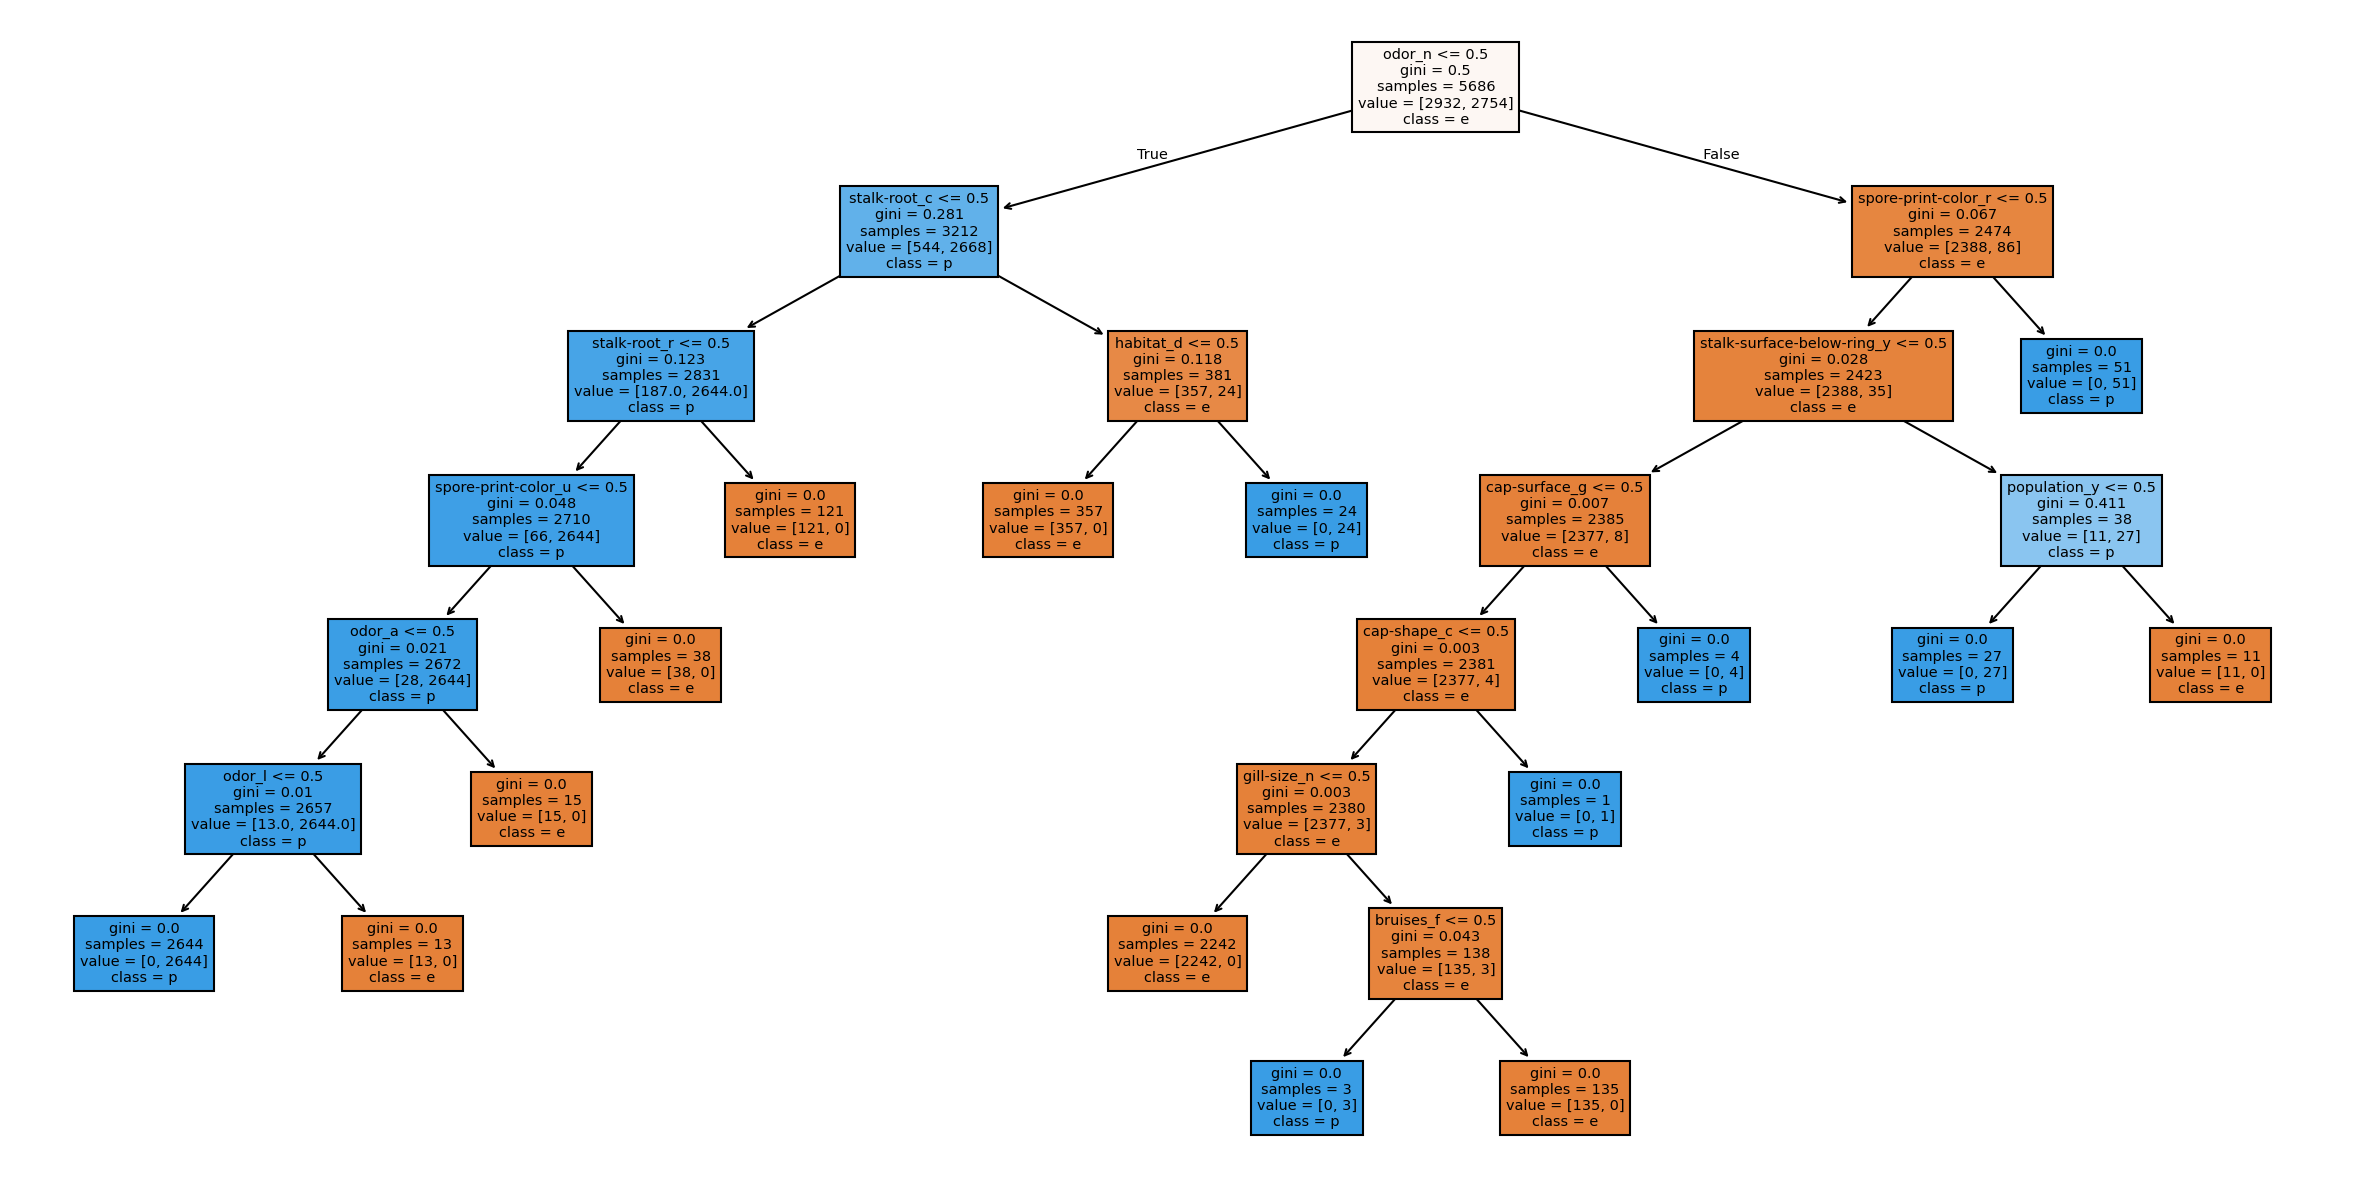

In [27]:
# 트리모델 시각화
# 시각화 도구 불러오기
from sklearn.tree import plot_tree

# matplotlib 설정
plt.figure(figsize = (20, 10), dpi = 150)

# 트라 시각화
plot_tree(tree1,   # 모델 지정
          filled = True,   # 색상 채우기
          feature_names = X_oh.columns,   # 특성이름 표시하기
          class_names = ['e', 'p'],   # 정답 이름 표시하기
          )
plt.show()

# 가지치기 색깔의 차이
# 색이 옅을수록 옅을수록 지니 불순도가 높은 상태(잘 섞이 상태)
# 색이 짙을수록 지니 불순도가 낮아진 상태(잘 안섞여진 상태)

In [28]:
y.unique()

array(['p', 'e'], dtype=object)

In [ ]:
# 하이퍼 파라미터 조절하기
# max_depth = n    => 깊이 조절
tree2 = DecisionTreeClassifier(max_depth = 3)

In [30]:
# 모델 학습하기
tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
# 점수 체크 해보기
tree2.score(X_test, y_test)

0.9856439704675964

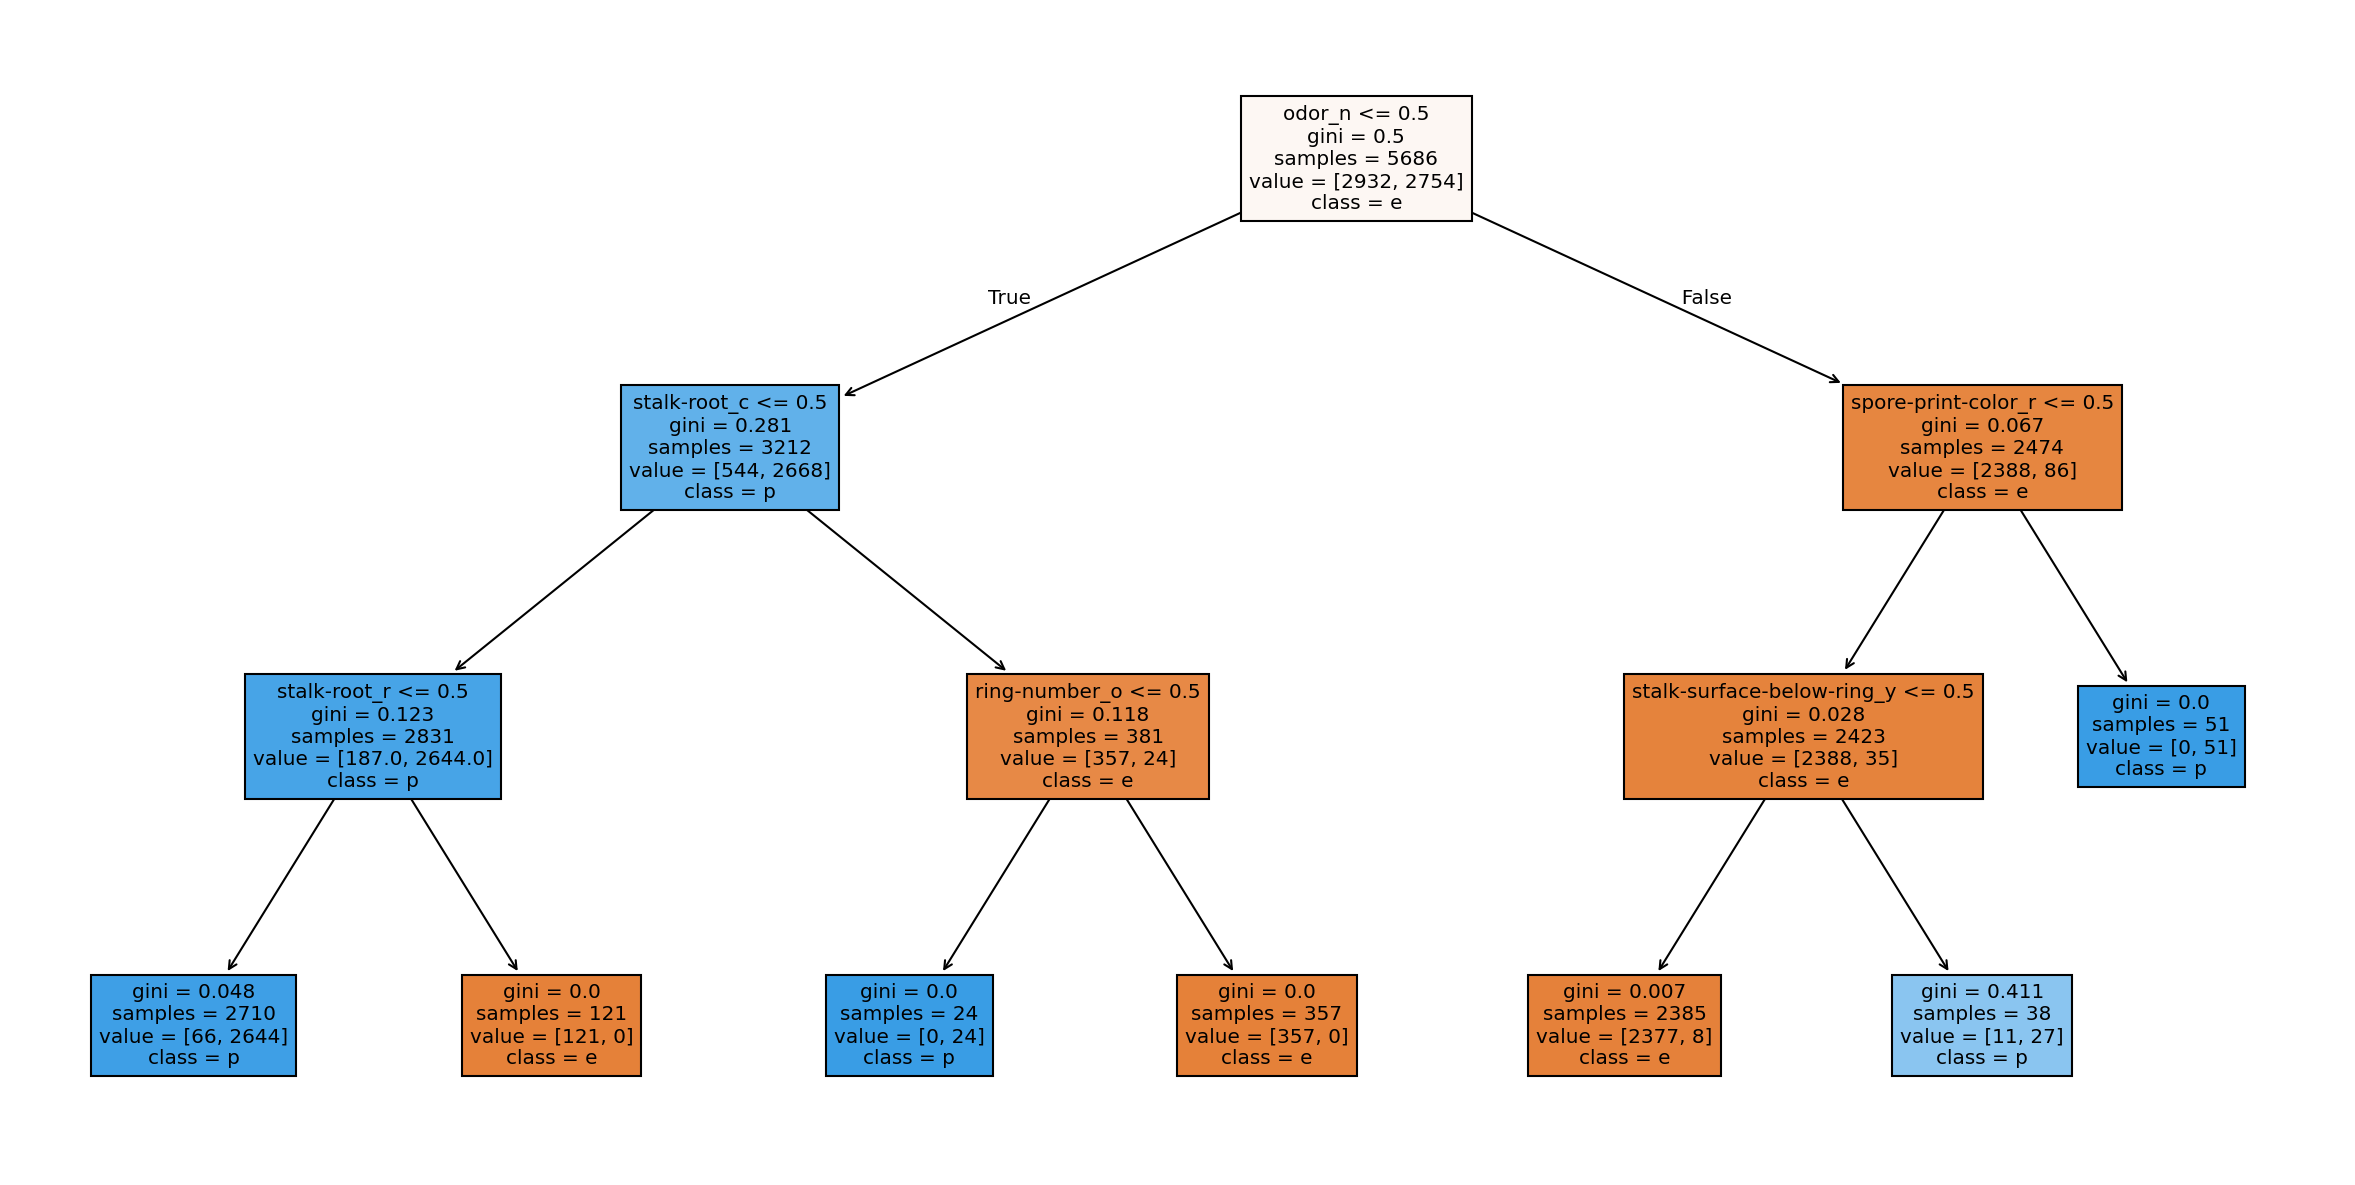

In [32]:
# 트리모델 시각화
# 시각화 도구 불러오기
from sklearn.tree import plot_tree

# matplotlib 설정
plt.figure(figsize = (20, 10), dpi = 150)

# 트라 시각화
plot_tree(tree2,   # 모델 지정
          filled = True,   # 색상 채우기
          feature_names = X_oh.columns,   # 특성이름 표시하기
          class_names = ['e', 'p'],   # 정답 이름 표시하기
          )
plt.show()

# 가지치기 색깔의 차이
# 색이 옅을수록 옅을수록 지니 불순도가 높은 상태(잘 섞이 상태)
# 색이 짙을수록 지니 불순도가 낮아진 상태(잘 안섞여진 상태)

# 세부 분할을 줄이고 정확도는 조금 떨어지지만 활용도가 좋음

In [33]:
# 현재 그래프를 살펴봤을때 Root Node(뿌리 노드)에 항상 odor_n이 나오는 것을 볼 수 있다
# 이유는 무엇인가?
# 특성 중요도를 살펴보고 정답 예측에 많은 영향을 미치는 컬럼을 살펴보자
fi = tree1.feature_importances_
fi

# 알파벳을 기준으로 좌, 우를 나눔
# 좌로 소숫점 기준 이동
# e 뒤의 - 는 얼만큼 왼쪽으로 갈지 + 는 오른쪽으로 갈지
# ex) 7.02103219e-04 => 0.0007

array([0.00000000e+00, 7.02103219e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.80252522e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.06659270e-03, 0.00000000e+00, 1.04007607e-02, 0.00000000e+00,
       0.00000000e+00, 9.10945096e-03, 0.00000000e+00, 6.23355113e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.32614456e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.79373456e-01, 0.00000000e+00, 7.76386661e-02,
      

In [34]:
# 데이터프레임으로 만들기
fi_df = pd.DataFrame(fi,
                     index = X_train.columns,
                     columns = ['특성중요도'])
fi_df

,특성중요도
cap-shape_b,0.000000
cap-shape_c,0.000702
cap-shape_f,0.000000
cap-shape_k,0.000000
cap-shape_s,0.000000
...,...
habitat_l,0.000000
habitat_m,0.000000
habitat_p,0.000000
habitat_u,0.000000


In [35]:
# 위에서 만든 데이터프레임을 내림차순 정렬해서 특성중요도가 높은 것 부터 보기
fi_df.sort_values(by = '특성중요도', ascending = False)

,특성중요도
odor_n,0.623355
stalk-root_c,0.179373
stalk-root_r,0.077639
spore-print-color_r,0.034164
spore-print-color_u,0.025833
...,...
gill-color_e,0.000000
gill-color_b,0.000000
gill-size_b,0.000000
gill-spacing_w,0.000000


In [ ]:
# 특성의 합 (열의 합)
# fi_df.sort_values(by = '특성중요도', ascending = False).sum()
fi_df.sum()   # 위랑 같음

특성중요도    1.0
dtype: float64

### 교차 검증


In [39]:
# 교차검증 도구 불러오기
from sklearn.model_selection import cross_val_score

# 교차검증 실행하기
# esult = cross_val_score(모델, , X_train, y_train, cv = 데이터 분할 갯수)
result = cross_val_score(tree1, X_train, y_train, cv = 5)

# 결과 확인하기
print(result)

# 결과 평균 확인하기
print(result.mean())

[1. 1. 1. 1. 1.]
1.0


In [41]:
# 교차검증 도구 불러오기
from sklearn.model_selection import cross_val_score

# 교차검증 실행하기
# esult = cross_val_score(모델, , X_train, y_train, cv = 데이터 분할 갯수)
result = cross_val_score(tree2, X_train, y_train, cv = 5)

# 결과 확인하기
print(result)

# 결과 평균 확인하기
print(result.mean())

[0.98330404 0.98944591 0.98240985 0.98504837 0.98504837]
0.9850513097551137
